In [1]:
## General imports
import os
os.environ["R_HOME"] = r"C:\Program Files\R\R-4.0.3"
os.environ["PATH"]   = r"C:\Program Files\R\R-4.0.3\bin\x64" + ";" + os.environ["PATH"]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as colmap
import seaborn as sns
import pingouin as pg
import re
import pickle
from scipy.stats import pearsonr
## Long import for torch and neuralop
import torch
import torch.nn as nn
from neuralop.models import FNO
## Local imports
from set_tex_fonts import set_latex_font
from motor_control_tools.adapted_processing import *
import motor_control_tools.figures as figures
import motor_control_tools.signal as signal
import manage_expe as me
import motor_control_tools as mct

****
Working on Transp_2DDL data
****


/home/dorian-verdel/Documents/Travail/Postdoc_PEPR/Code/Traitement_donnees_manip_Transp2DDL/motor_control_tools/robot_processing.py:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  et $\Delta{q}$ est le décalage angulaire moyen que nous identifions


In [2]:
## Load population kinematics
all_qtm_data = pd.read_csv("./all_params/Transp_2DDL_index_cut-off-rel-5.csv", encoding = "ISO-8859-1", engine='python')
all_rob_data = pd.read_csv("./all_params/Transp_2DDL_rob_cut-off-rel-5.csv", encoding = "ISO-8859-1", engine='python')

## Extract best transparency data
all_qtm_data_TR = all_qtm_data[all_qtm_data['condition'] == 'OLCL']
all_rob_data_TR = all_rob_data[all_rob_data['condition'] == 'OLCL']
all_rob_data_TR

,subject,condition,block,movement,UpDown dir,MD,AmpFA,mVelFA,PVelFA,tPVelFA,...,avFxA,avFyA,avFzA,avTxA,avTyA,avTzA,workA,file_name,target,direction
240,S1,OLCL,1.0,0,NaN,0.249342,0.361056,1.448034,5.410514,0.125383,...,7.442468,5.680084,4.826002,0.671489,1.387931,0.232777,0.000422,./Transp_2DDL/data/movements/rob_S1_OLCL_m0.pi...,5,forward
241,S1,OLCL,1.0,1,NaN,0.472264,0.491761,1.041284,3.167086,0.090770,...,5.160309,4.707933,5.101424,0.456096,0.757796,0.390460,-0.000216,./Transp_2DDL/data/movements/rob_S1_OLCL_m1.pi...,5,backward
242,S1,OLCL,1.0,2,NaN,0.231888,0.703356,3.033176,6.714031,0.092354,...,4.118464,8.157888,3.931119,0.703857,0.683894,0.299717,-0.000007,./Transp_2DDL/data/movements/rob_S1_OLCL_m2.pi...,2,forward
243,S1,OLCL,1.0,3,NaN,0.338159,0.753997,2.229711,5.612752,0.096241,...,3.178356,6.146539,5.216433,0.356805,0.409807,0.243642,0.001072,./Transp_2DDL/data/movements/rob_S1_OLCL_m3.pi...,2,backward
244,S1,OLCL,1.0,4,NaN,0.270450,0.603271,2.230615,5.514129,0.147030,...,10.395082,6.128102,4.738390,0.621122,1.287522,0.214305,-0.000212,./Transp_2DDL/data/movements/rob_S1_OLCL_m4.pi...,5,forward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4417,S9,OLCL,1.0,75,NaN,0.299524,1.136467,3.794251,7.714468,0.067114,...,2.767589,4.686922,1.964691,0.570577,0.457096,0.472129,0.000166,./Transp_2DDL/data/movements/rob_S9_OLCL_m75.p...,1,backward
4418,S9,OLCL,1.0,76,NaN,0.262793,0.818322,3.113941,6.967468,0.145059,...,4.232294,4.950032,3.268862,0.434091,0.250881,0.280616,0.000279,./Transp_2DDL/data/movements/rob_S9_OLCL_m76.p...,3,forward
4419,S9,OLCL,1.0,77,NaN,0.391890,0.962979,2.457267,5.219226,0.137025,...,2.863110,6.142057,3.147070,0.696358,0.357980,0.244029,-0.000049,./Transp_2DDL/data/movements/rob_S9_OLCL_m77.p...,3,backward
4420,S9,OLCL,1.0,78,NaN,0.263762,0.983844,3.730040,7.074294,0.188162,...,6.456056,6.894361,3.475801,0.552742,0.361047,0.353796,0.000680,./Transp_2DDL/data/movements/rob_S9_OLCL_m78.p...,3,forward


In [3]:
## Build well formatted set of batch
d_in = 4 + 12 + 2 # 4 robot joint angles & velocities + 12 forces + 2 anthropometric parameters
d_out = 4 # 4 human joint angles & velocities
subjList = ['S1', 'S2', 'S3', 'S5', 'S6', 'S7', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16']

all_data_subj = []
for subj in subjList:
    df_one_subj_h = all_qtm_data_TR[all_qtm_data_TR['subject'] == subj]
    df_one_subj_r = all_rob_data_TR[all_rob_data_TR['subject'] == subj]

    subj_mat = get_all_aligned_hr_joints_mvts_one_subj(df_one_subj_h, df_one_subj_r, subj = subj, cut = 0.05)
    for mvt in np.unique(subj_mat[:,23]):
        mvt_mat = subj_mat[subj_mat[:,23] == mvt]
        mvt_mat = mvt_mat[:,0:22]
        if not np.isnan(mvt_mat).any():
            resampled_mvt_mat = mct.signal.resample_by_interpolation(mvt_mat, fixed_outlen=True, outlen=1000)
            all_data_subj.append(resampled_mvt_mat)

## Dimension of the dataset is (number of movements, number of time steps, number of features)
print("Full dataset shape:", str(np.shape(all_data_subj)))

## Extract input and output np.array data for the FNO
X_np = np.array(all_data_subj)[:,:,0:d_in] # input is the first 6 columns (robot joint angles & velocities and anthropometric parameters)
Y_np = np.array(all_data_subj)[:,:,d_in:d_in+d_out] # output is the last 4 columns (human joint angles & velocities)

## Switch to torch tensors for the FNO
X = torch.from_numpy(X_np).float()
Y = torch.from_numpy(Y_np).float()

## Permute for FNO
X = X.permute(0, 2, 1)  # (batch, d_in, seq_len)
Y = Y.permute(0, 2, 1)  # (batch, d_out, seq_len)

## Check shapes
print("Input shape:", str(np.shape(X)))
print("Output shape:", str(np.shape(Y)))

Bounds human:  [95, 305]
Bounds robot:  [265, 475]
Bounded forces shape:  (210, 12)
Bounds human:  [207, 397]
Bounds robot:  [308, 498]
Bounded forces shape:  (190, 12)
Bounds human:  [102, 318]
Bounds robot:  [189, 405]
Bounded forces shape:  (216, 12)
Bounds human:  [118, 333]
Bounds robot:  [252, 467]
Bounded forces shape:  (215, 12)
Bounds human:  [81, 291]
Bounds robot:  [152, 362]
Bounded forces shape:  (210, 12)
Bounds human:  [112, 748]
Bounds robot:  [234, 870]
Bounded forces shape:  (636, 12)
Bounds human:  [193, 400]
Bounds robot:  [354, 561]
Bounded forces shape:  (207, 12)
Bounds human:  [140, 3358]
Bounds robot:  [220, 3438]
Bounded forces shape:  (3218, 12)
Bounds human:  [96, 312]
Bounds robot:  [225, 441]
Bounded forces shape:  (216, 12)
Bounds human:  [90, 373]
Bounds robot:  [252, 535]
Bounded forces shape:  (283, 12)
Bounds human:  [120, 360]
Bounds robot:  [220, 460]
Bounded forces shape:  (240, 12)
Bounds human:  [87, 447]
Bounds robot:  [224, 584]
Bounded forces 

In [4]:
print(torch.isnan(X).any())
print(torch.isnan(Y).any())

tensor(False)
tensor(False)


In [ ]:
## Number of folds
nb_folds = [2,5]

## Model structure
nb_modes = [2,4,8,16,32,64]
nb_hidChan = [8,16,32,64,128]

## Loop on available model parameters

## Create FNO model
model = FNO(
    n_modes = (32,),
    hidden_channels = 64,
    in_channels = d_in,
    out_channels = d_out
)

## Create optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

prev_loss = 1
## Train the model
for epoch in range(500):
    optimizer.zero_grad()
    
    Y_pred = model(X)
    loss = loss_fn(Y_pred, Y)
    
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

    if np.abs(loss.item()-prev_loss) < 0.00001:
        print("Converged")
        break

    prev_loss = loss.item()

Epoch 0: Loss = 0.368682
Epoch 1: Loss = 0.310428
Epoch 2: Loss = 0.264420
Epoch 3: Loss = 0.228627
Epoch 4: Loss = 0.204606


KeyboardInterrupt: 

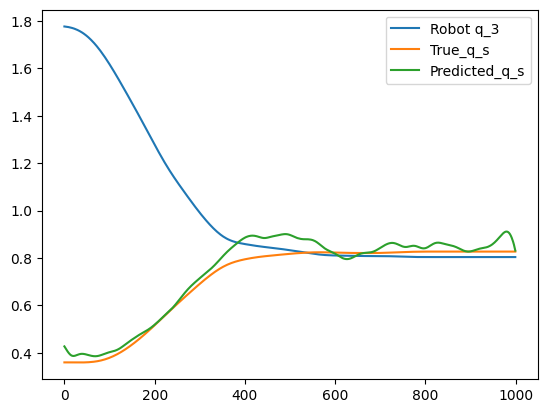

In [14]:
## Test the model on a sample input
i = 15
test_input = X[i,:,:].unsqueeze(0)  # (1, d_in, seq_len)
pred = model(test_input)

plt.plot(X[i,0,:].numpy(), label='Robot q_3')
plt.plot(Y[i,0,:].numpy(), label='True_q_s')
plt.plot(pred[0,0,:].detach().numpy(), label='Predicted_q_s')
plt.legend()
plt.show()